In [227]:
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

import scipy.stats as sts

In [228]:
mu = 5
n = 100

X = np.random.normal(mu, 1, n)

theta_hat = np.exp(np.mean(X))
theta_hat

np.float64(140.62593984791053)

In [229]:
X

array([4.49632624, 5.64081815, 4.84186904, 5.60541227, 6.16682867,
       3.32508635, 5.89185187, 6.9776771 , 6.66928888, 4.64748545,
       5.5210727 , 5.5714289 , 5.05832485, 5.15426313, 4.79785141,
       4.58835693, 4.73910852, 4.96467374, 4.65809406, 6.25647408,
       5.13236246, 4.71531421, 5.26707233, 5.30843643, 3.7938678 ,
       3.32759493, 4.10545449, 5.09715946, 4.72350403, 4.05766103,
       4.07736676, 3.79191801, 3.16065245, 5.41861461, 5.37245855,
       4.92863092, 5.70473956, 5.00922943, 6.98208148, 4.7627887 ,
       6.87456974, 4.35957867, 3.7750352 , 4.04773045, 4.88338599,
       5.31223376, 5.89728174, 5.78016985, 4.11394716, 6.03493317,
       5.52238572, 4.44168091, 5.6670899 , 4.07071426, 4.88078387,
       5.73857915, 3.7430213 , 4.62573391, 3.9560522 , 5.1462888 ,
       3.57503349, 4.78497518, 4.6437337 , 4.85819951, 4.67164685,
       4.8989878 , 5.96293602, 4.42191901, 5.57165728, 3.76254237,
       4.84639611, 5.39882561, 5.71955121, 3.4410103 , 3.85483

In [230]:
B = 10000
boot_theta = np.zeros(B)

for b in range(B):
    sample = np.random.choice(X, size=n, replace=True)
    boot_theta[b] = np.exp(np.mean(sample))

In [231]:
se_boot = np.std(boot_theta, ddof=1)
se_boot

np.float64(13.06226479661407)

In [232]:
ci = np.quantile(boot_theta, [0.025, 0.975])
ci

array([117.12147557, 168.09574115])

In [233]:
s = np.sqrt(1/n)
true_dist = sts.lognorm(s=s, scale=np.exp(mu))

true_sample = true_dist.rvs(B)

In [234]:
x = np.linspace(min(boot_theta), max(boot_theta), 1000)
pdf = true_dist.pdf(x)

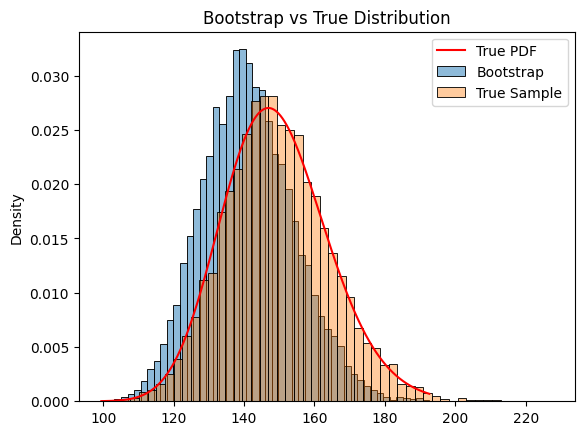

In [235]:
sns.histplot(boot_theta, bins=50, stat="density", alpha=0.5, label="Bootstrap")
sns.histplot(true_sample, bins=50, stat="density", alpha=0.4, label="True Sample")
plt.plot(x, pdf, 'r', label="True PDF")

plt.legend()
plt.title("Bootstrap vs True Distribution")
plt.show()